<a href="https://colab.research.google.com/github/vikagrishina/My_First_Test_Repo/blob/main/%D0%9B%D0%A02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЗАГОЛОВОК (названия столбцов):
['Wind_power_MW', 'Solar_power_kW', 'Consumption_MW']

ПЕРВЫЕ 5 СТРОК:
   Wind_power_MW  Solar_power_kW  Consumption_MW
0      65.655516          0.0000           34.70
1      69.111069          0.0000           32.79
2      72.134678        178.6368           33.09
3      75.590232        721.5360           33.63
4      68.247181       3752.5248           34.51

ПОСЛЕДНИЕ 5 СТРОК:
      Wind_power_MW  Solar_power_kW  Consumption_MW
8755     128.719366             0.0           45.47
8756     129.583255             0.0           40.72
8757     130.447143             0.0           39.11
8758     132.606864             0.0           36.91
8759     134.766585             0.0           35.58

СТАТИСТИКА ПО ДАННЫМ:
       Wind_power_MW  Solar_power_kW  Consumption_MW
count    8760.000000     8760.000000     8760.000000
mean       91.842674     1557.825929       31.154526
std        38.617121     2384.385076        8.008808
min         1.295833        0.000000 

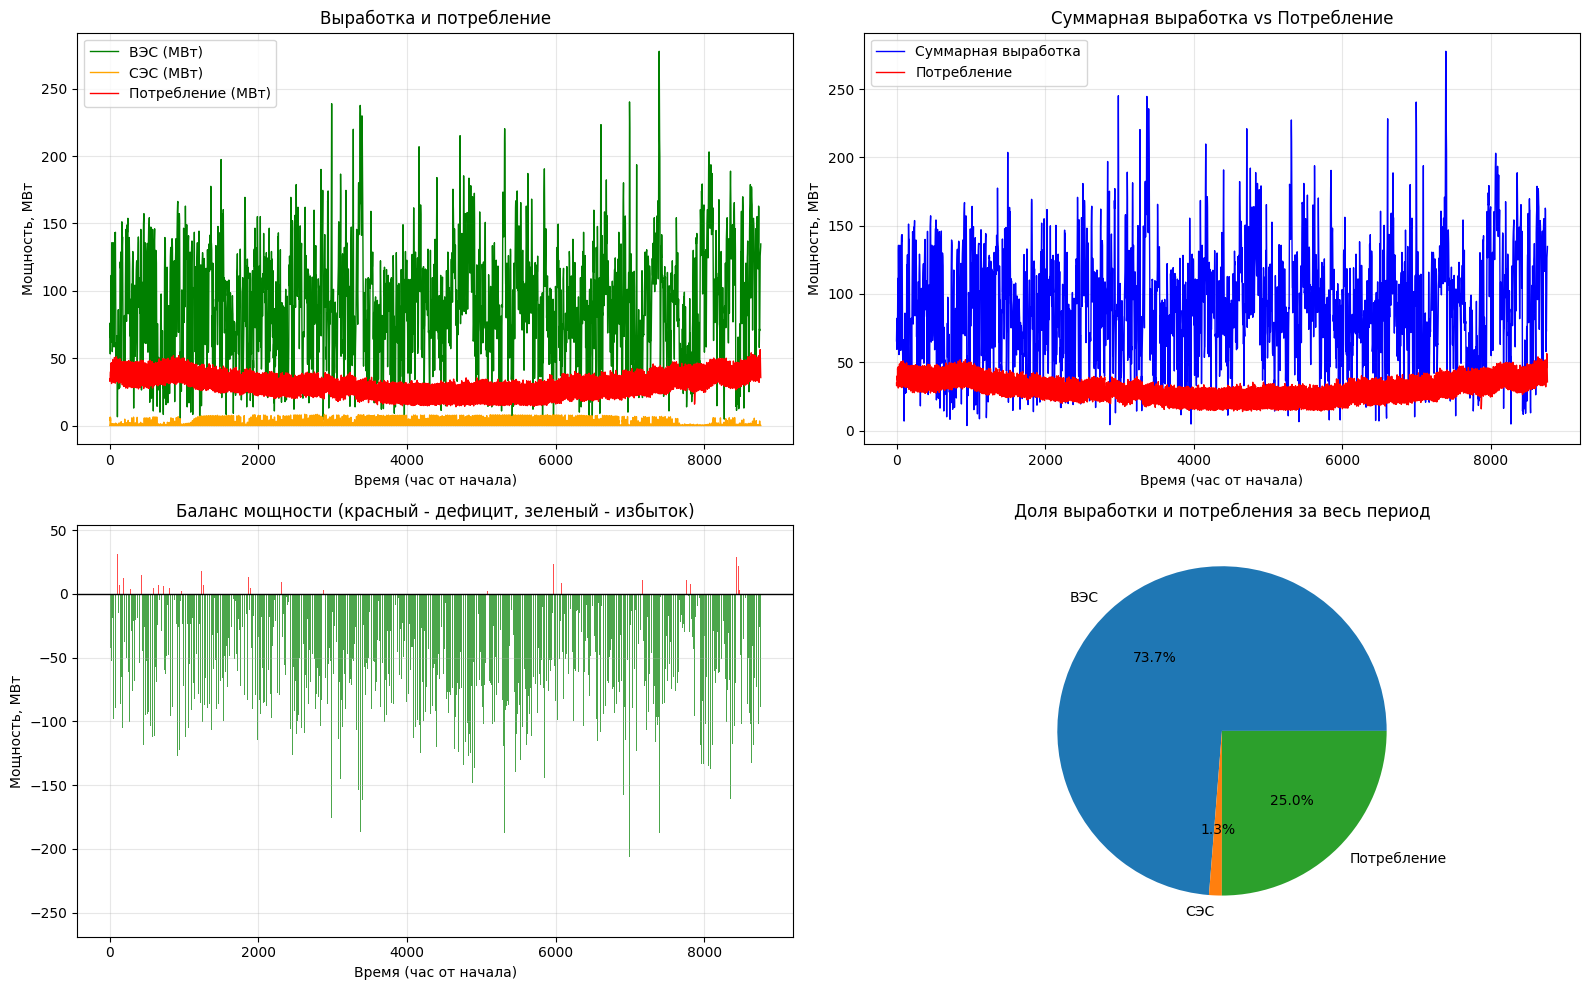


СОХРАНЕННЫЕ ФАЙЛЫ:
 static_plots.png / .pdf - статические графики
 interactive_balance.html - интерактивный график (открывается в браузере)
 prosumer_detailed.xlsx / .csv - детальные данные
 summary_results.xlsx / .csv - итоговые результаты

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
Количество часов в данных: 8760
Диапазон часов: с 0 по 8759
Максимальная выработка ВЭС: 277.74 МВт
Максимальная выработка СЭС: 8.36 МВт
Максимальное потребление: 56.29 МВт


In [3]:
# ============================================
# ЛАБОРАТОРНАЯ РАБОТА №2
# Вариант 4: Wind_Solar_Consumption.csv


# 1. Подключение библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# 2. Загрузка данных (используем загруженный файл)

df = pd.read_csv('Wind_Solar_Consumption.csv')

# 3. Вывод информации о данных (п.3 задания)
print("=" * 60)
print("ЗАГОЛОВОК (названия столбцов):")
print(df.columns.tolist())
print("\n" + "=" * 60)
print("ПЕРВЫЕ 5 СТРОК:")
print(df.head())
print("\n" + "=" * 60)
print("ПОСЛЕДНИЕ 5 СТРОК:")
print(df.tail())
print("\n" + "=" * 60)
print("СТАТИСТИКА ПО ДАННЫМ:")
print(df.describe())

# 4. Приведение единиц измерения (Solar_power_kW -> MW)
df['Solar_power_MW'] = df['Solar_power_kW'] / 1000

# 5. Расчет суммарной выработки и баланса
df['Total_generation_MW'] = df['Wind_power_MW'] + df['Solar_power_MW']
df['Balance_MW'] = df['Consumption_MW'] - df['Total_generation_MW']

# 6. Расчет энергии (п.5 задания)
# Так как данные почасовые, энергия (МВт·ч) = мощность (МВт) × 1 час
energy_to_buy = df[df['Balance_MW'] > 0]['Balance_MW'].sum()      # нужно купить
energy_to_sell = abs(df[df['Balance_MW'] < 0]['Balance_MW'].sum()) # можно продать

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ РАСЧЕТА ПО ЗАДАНИЮ:")
print(f" Энергии, которую нужно КУПИТЬ: {energy_to_buy:.2f} МВт·ч")
print(f"Энергии, которую можно ПРОДАТЬ: {energy_to_sell:.2f} МВт·ч")
if energy_to_buy > energy_to_sell:
    print(f" ИТОГО нужно купить: {energy_to_buy - energy_to_sell:.2f} МВт·ч")
else:
    print(f" ИТОГО можно продать: {energy_to_sell - energy_to_buy:.2f} МВт·ч")
print("=" * 60)

# 7. Создание индекса времени (по порядку, так как временной метки нет)
df['hour'] = range(len(df))

# 8. СТАТИЧЕСКИЕ ГРАФИКИ (Matplotlib) - п.4 задания
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# График 1: Выработка ВЭС, СЭС и потребление
axes[0, 0].plot(df['hour'], df['Wind_power_MW'], label='ВЭС (МВт)', color='green', linewidth=1)
axes[0, 0].plot(df['hour'], df['Solar_power_MW'], label='СЭС (МВт)', color='orange', linewidth=1)
axes[0, 0].plot(df['hour'], df['Consumption_MW'], label='Потребление (МВт)', color='red', linewidth=1)
axes[0, 0].set_title('Выработка и потребление')
axes[0, 0].set_xlabel('Время (час от начала)')
axes[0, 0].set_ylabel('Мощность, МВт')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Суммарная выработка vs Потребление
axes[0, 1].plot(df['hour'], df['Total_generation_MW'], label='Суммарная выработка', color='blue', linewidth=1)
axes[0, 1].plot(df['hour'], df['Consumption_MW'], label='Потребление', color='red', linewidth=1)
axes[0, 1].set_title('Суммарная выработка vs Потребление')
axes[0, 1].set_xlabel('Время (час от начала)')
axes[0, 1].set_ylabel('Мощность, МВт')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Баланс мощности (красный - покупка, зеленый - продажа)
colors = ['red' if x > 0 else 'green' for x in df['Balance_MW']]
axes[1, 0].bar(df['hour'], df['Balance_MW'], color=colors, alpha=0.7, width=0.8)
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_title('Баланс мощности (красный - дефицит, зеленый - избыток)')
axes[1, 0].set_xlabel('Время (час от начала)')
axes[1, 0].set_ylabel('Мощность, МВт')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Круговая диаграмма (пример 5.1.10 из методички)
total_wind = df['Wind_power_MW'].sum()
total_solar = df['Solar_power_MW'].sum()
total_consumption = df['Consumption_MW'].sum()
axes[1, 1].pie([total_wind, total_solar, total_consumption],
               labels=['ВЭС', 'СЭС', 'Потребление'],
               autopct='%1.1f%%')
axes[1, 1].set_title('Доля выработки и потребления за весь период')

plt.tight_layout()
plt.savefig('static_plots.png', dpi=150)
plt.savefig('static_plots.pdf')
plt.show()

# 9. ИНТЕРАКТИВНЫЙ ГРАФИК (Plotly) - п.6 задания
fig_int = go.Figure()

# Добавляем линии
fig_int.add_trace(go.Scatter(
    x=df['hour'],
    y=df['Wind_power_MW'],
    mode='lines',
    name='ВЭС (МВт)',
    line=dict(color='green', width=1)
))

fig_int.add_trace(go.Scatter(
    x=df['hour'],
    y=df['Solar_power_MW'],
    mode='lines',
    name='СЭС (МВт)',
    line=dict(color='orange', width=1)
))

fig_int.add_trace(go.Scatter(
    x=df['hour'],
    y=df['Consumption_MW'],
    mode='lines',
    name='Потребление (МВт)',
    line=dict(color='red', width=2)
))

fig_int.add_trace(go.Scatter(
    x=df['hour'],
    y=df['Balance_MW'],
    mode='lines',
    name='Баланс (МВт)',
    line=dict(color='blue', width=2, dash='dash')
))

# Подсветка областей баланса
fig_int.add_trace(go.Scatter(
    x=df['hour'],
    y=df['Balance_MW'].clip(lower=0),
    mode='lines',
    name=' Дефицит (нужно купить)',
    fill='tozeroy',
    line=dict(color='red', width=0),
    fillcolor='rgba(255,0,0,0.3)'
))

fig_int.add_trace(go.Scatter(
    x=df['hour'],
    y=df['Balance_MW'].clip(upper=0),
    mode='lines',
    name=' Избыток (можно продать)',
    fill='tozeroy',
    line=dict(color='green', width=0),
    fillcolor='rgba(0,255,0,0.3)'
))

fig_int.update_layout(
    title='Интерактивный график: Выработка, потребление и баланс активного потребителя',
    xaxis_title='Время (час от начала)',
    yaxis_title='Мощность, МВт',
    hovermode='x unified',
    width=1200,
    height=600,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)')
)

fig_int.show()

# 10. Сохранение интерактивного графика (п.7 задания)
fig_int.write_html('interactive_balance.html')
# Для сохранения как PNG нужен kaleido: pip install -U kaleido
# fig_int.write_image('interactive_balance.png')

# 11. Сохранение результатов в Excel и CSV (п.7 задания)
# Детальные данные
df_results = df[['hour', 'Wind_power_MW', 'Solar_power_MW', 'Solar_power_kW',
                 'Consumption_MW', 'Total_generation_MW', 'Balance_MW']].copy()
df_results.to_excel('prosumer_detailed.xlsx', index=False)
df_results.to_csv('prosumer_detailed.csv', index=False, encoding='utf-8-sig')

# Итоговые цифры
summary = pd.DataFrame({
    'Показатель': [
        'Всего выработано ВЭС (МВт·ч)',
        'Всего выработано СЭС (МВт·ч)',
        'Всего выработано (суммарно) (МВт·ч)',
        'Всего потреблено (МВт·ч)',
        'Нужно купить (МВт·ч)',
        'Можно продать (МВт·ч)',
        'Итоговый баланс (МВт·ч)'
    ],
    'Значение': [
        df['Wind_power_MW'].sum(),
        df['Solar_power_MW'].sum(),
        df['Total_generation_MW'].sum(),
        df['Consumption_MW'].sum(),
        energy_to_buy,
        energy_to_sell,
        energy_to_buy - energy_to_sell
    ]
})
summary.to_csv('summary_results.csv', index=False, encoding='utf-8-sig')
summary.to_excel('summary_results.xlsx', index=False)

print("\n" + "=" * 60)
print("СОХРАНЕННЫЕ ФАЙЛЫ:")
print(" static_plots.png / .pdf - статические графики")
print(" interactive_balance.html - интерактивный график (открывается в браузере)")
print(" prosumer_detailed.xlsx / .csv - детальные данные")
print(" summary_results.xlsx / .csv - итоговые результаты")
print("=" * 60)

# 12. Дополнительная информация для отчета
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print(f"Количество часов в данных: {len(df)}")
print(f"Диапазон часов: с 0 по {len(df)-1}")
print(f"Максимальная выработка ВЭС: {df['Wind_power_MW'].max():.2f} МВт")
print(f"Максимальная выработка СЭС: {df['Solar_power_MW'].max():.2f} МВт")
print(f"Максимальное потребление: {df['Consumption_MW'].max():.2f} МВт")
print("=" * 60)